# Predictive Coding End-Stopping Experiment

## Overview

This experiment demonstrates the **end-stopping phenomenon** using a predictive coding framework.

A model is first trained on **natural image patches from CIFAR** to learn edge-like filters.
Then **synthetic bar stimuli** of varying length are presented to measure neuron responses.

The goal is to observe how contextual information from surrounding patches reduces prediction error for long bars.

---

## Predictive Coding Model

The predictive coding framework assumes that an image patch $I$ can be reconstructed from a latent representation $r$:

$$
I = U r
$$

Where:

- $I$ = image patch
- $U$ = basis matrix (learned filters)
- $r$ = latent representation

---

## Representation Inference

The latent representation is updated iteratively to minimize prediction error.

Prediction error:

$$
e = I - U r
$$

Update rule:

$$
r_{t+1} = r_t + \eta U^T (I - U r_t)
$$

Where:

- $\eta$ = learning rate
- $U^T$ = transpose of the basis matrix

---

## Learning Rule

The basis matrix is updated using a Hebbian-style learning rule:

$$
U_{new} = U + \eta (e r^T)
$$

Where:

- $e = I - Ur$ is the prediction error
- $r^T$ is the transpose of the latent representation

---

## Predictive Coding with Context

Predictive coding assumes that surrounding patches can predict the center patch.

If

- $r_L$ = representation of left patch
- $r_R$ = representation of right patch

Then the predicted center representation is:

$$
r_{td} = \frac{r_L + r_R}{2}
$$

The **error neuron response** is defined as:

$$
e = r_C - r_{td}
$$

Where:

- $r_C$ = representation of the center patch
- $r_{td}$ = top-down prediction

The measured response is:

$$
Response = || r_C - r_{td} ||
$$

---

## Experiment Pipeline

1. Load CIFAR natural images  
2. Extract image patches  
3. Train predictive coding filters  
4. Generate synthetic bar stimuli  
5. Extract left, center, and right patches  
6. Compute contextual prediction  
7. Measure prediction error  
8. Plot neuron response vs bar length

---

# Importing Libraries

In [56]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Loading CIFAR Dataset

In [57]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Extracting Three Overlapping Patches

In [58]:
def extract_three_patches(img, size=16, offset=5):

    _, H, W = img.shape

    max_x = W - (size + 2*offset)
    max_y = H - size

    x = int(torch.randint(0, max_x+1,(1,)).item())
    y = int(torch.randint(0, max_y+1,(1,)).item())

    left   = img[:, y:y+size, x:x+size]
    center = img[:, y:y+size, x+offset:x+offset+size]
    right  = img[:, y:y+size, x+2*offset:x+2*offset+size]

    return (
        left.reshape(-1),
        center.reshape(-1),
        right.reshape(-1)
    )

# Initializing Model Parameters

In [59]:
patch_size = 16*16
latent_dim = 32

U = torch.randn(patch_size, latent_dim)*0.1

# Predictive Coding Inference

In [60]:
def infer(patch, U, steps=20, lr=0.01):

    r = torch.zeros(U.shape[1])

    for _ in range(steps):

        pred = U @ r
        err = patch - pred

        r = r + lr*(U.T @ err)

    return r, err

# Training Model

In [61]:
lr = 0.01

for epoch in range(10):

    for img,_ in tqdm(dataset):

        left,center,right = extract_three_patches(img)

        rC,eC = infer(center,U)

        U += lr*torch.outer(eC,rC)

100%|██████████| 50000/50000 [00:55<00:00, 893.38it/s]


# Generating Bar Stimuli

In [62]:
def generate_large_bar(size=32,length=6):

    img = np.zeros((size,size))

    c = size//2
    s = c-length//2
    e = c+length//2

    img[c-1:c+1,s:e] = 1

    return torch.tensor(img,dtype=torch.float32)

# Extracting Bar Patches

In [63]:
def extract_bar_patches(img,size=16,offset=5):

    c = img.shape[0]//2
    x = c-size//2

    left   = img[c-size//2:c+size//2 , x-offset:x-offset+size]
    center = img[c-size//2:c+size//2 , x:x+size]
    right  = img[c-size//2:c+size//2 , x+offset:x+offset+size]

    return (
        left.reshape(-1),
        center.reshape(-1),
        right.reshape(-1)
    )

# Measuring Predictive Coding Response

In [64]:
responses=[]
lengths=list(range(2,14))

for L in lengths:

    img = generate_large_bar(length=L)

    left,center,right = extract_bar_patches(img)

    rL,_ = infer(left,U)
    rC,_ = infer(center,U)
    rR,_ = infer(right,U)

    r_td = 0.5*(rL+rR)

    response = torch.norm(rC-r_td).item()

    responses.append(response)

# Plotting End Stopping Curve

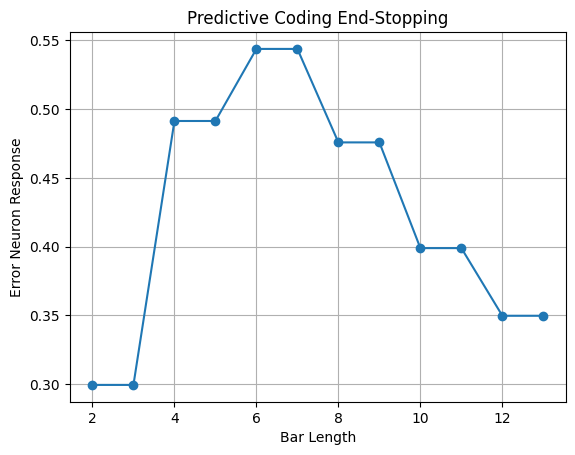

In [65]:
plt.plot(lengths,responses,'o-')
plt.xlabel("Bar Length")
plt.ylabel("Error Neuron Response")
plt.title("Predictive Coding End-Stopping")
plt.grid(True)
plt.show()